<a href="https://colab.research.google.com/github/SangeetBarkataki10/CS105Minproject-SSTMA/blob/sbark018/SSTMA_CS105.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ETL Pipeline

In [1]:
import pandas as pd

df = pd.read_csv("CS105_data.csv")

column_mapping = {
    # Demographics
    2: "Class Standing",
    13: "Cumulative GPA",

    # AI Reliance
    42: "LLM Frequency (ChatGPT)",
    43: "LLM Frequency (Claude)",
    44: "LLM Frequency (Gemini)",
    46: "LLM Frequency (Copilot)",
    47: "LLM Frequency (Perplexity)",
    48: "LLM Frequency (Deepseek)",
    86: "Math Usage",
    88: "CS Usage",
    89: "Data Science Usage",
    99: "AI Chatbot Usage",

    # Confidence in Original Work
    53: "Coding Self Confidence",
    54: "Research Self Confidence",
    55: "Data Analysis Self Confidence",
    56: "Writing Self Confidence",
    57: "Topic Summarization Self Confidence",
    107: "Agreement",
    62: "Overreliance Concern",
    59: "Loss of Learning Concern",

    # Trust in AI vs Need for Verification
    92: "Math Trust",
    94: "CS Trust",
    95: "Data Science Trust",
    61: "Hallucinations/Wrong Answers"
}

columns_to_keep = list(column_mapping.keys())
df_clean = df.iloc[:, columns_to_keep].copy()

rename_dict = {df.columns[i]: new_name for i, new_name in column_mapping.items()}
df_clean = df_clean.rename(columns=rename_dict)
df_clean.dropna(inplace=True)

df_clean.to_csv("CS105_data_clean.csv", index=False)

df_clean.head()

,Class Standing,Cumulative GPA,LLM Frequency (ChatGPT),LLM Frequency (Claude),LLM Frequency (Gemini),LLM Frequency (Copilot),LLM Frequency (Perplexity),LLM Frequency (Deepseek),Math Usage,CS Usage,...,Data Analysis Self Confidence,Writing Self Confidence,Topic Summarization Self Confidence,Agreement,Overreliance Concern,Loss of Learning Concern,Math Trust,CS Trust,Data Science Trust,Hallucinations/Wrong Answers
0,Senior,3.33 – 3.67,Use Frequently,Never Used,Used 1-2 times,Never Used,Never Used,Never Used,2.0,1.0,...,Fairly Confident,Very Confident,Very Confident,4.0,4 (Moderately influential),5 (Extremely influential),2.0,2.0,2.0,4 (Moderately influential)
1,Junior,3.67 – 4.0,Use Rarely,Never Used,Use Rarely,Use Rarely,Never Used,Never Used,2.0,3.0,...,Fairly Confident,Very Confident,Very Confident,1.0,5 (Extremely influential),4 (Moderately influential),4.0,4.0,4.0,3 (Partially Influential)
2,Junior,3.33 – 3.67,Use Frequently,Use Frequently,Use Rarely,Never Used,Never Used,Never Used,2.0,2.0,...,Somewhat Confident,Fairly Confident,Fairly Confident,2.0,3 (Partially Influential),2 (Somewhat influential),1.0,2.0,1.0,2 (Somewhat influential)
3,Senior,3.33 – 3.67,Use Frequently,Use Frequently,Used 1-2 times,Use Rarely,Never Used,Never Used,0.0,4.0,...,Somewhat Confident,Very Confident,Very Confident,5.0,5 (Extremely influential),5 (Extremely influential),5.0,5.0,0.0,2 (Somewhat influential)
4,Junior,3.33 – 3.67,Use Frequently,Never Used,Use Frequently,Use Frequently,Never Used,Use Rarely,2.0,2.0,...,Somewhat Confident,Somewhat Confident,Somewhat Confident,2.0,5 (Extremely influential),4 (Moderately influential),5.0,5.0,5.0,4 (Moderately influential)


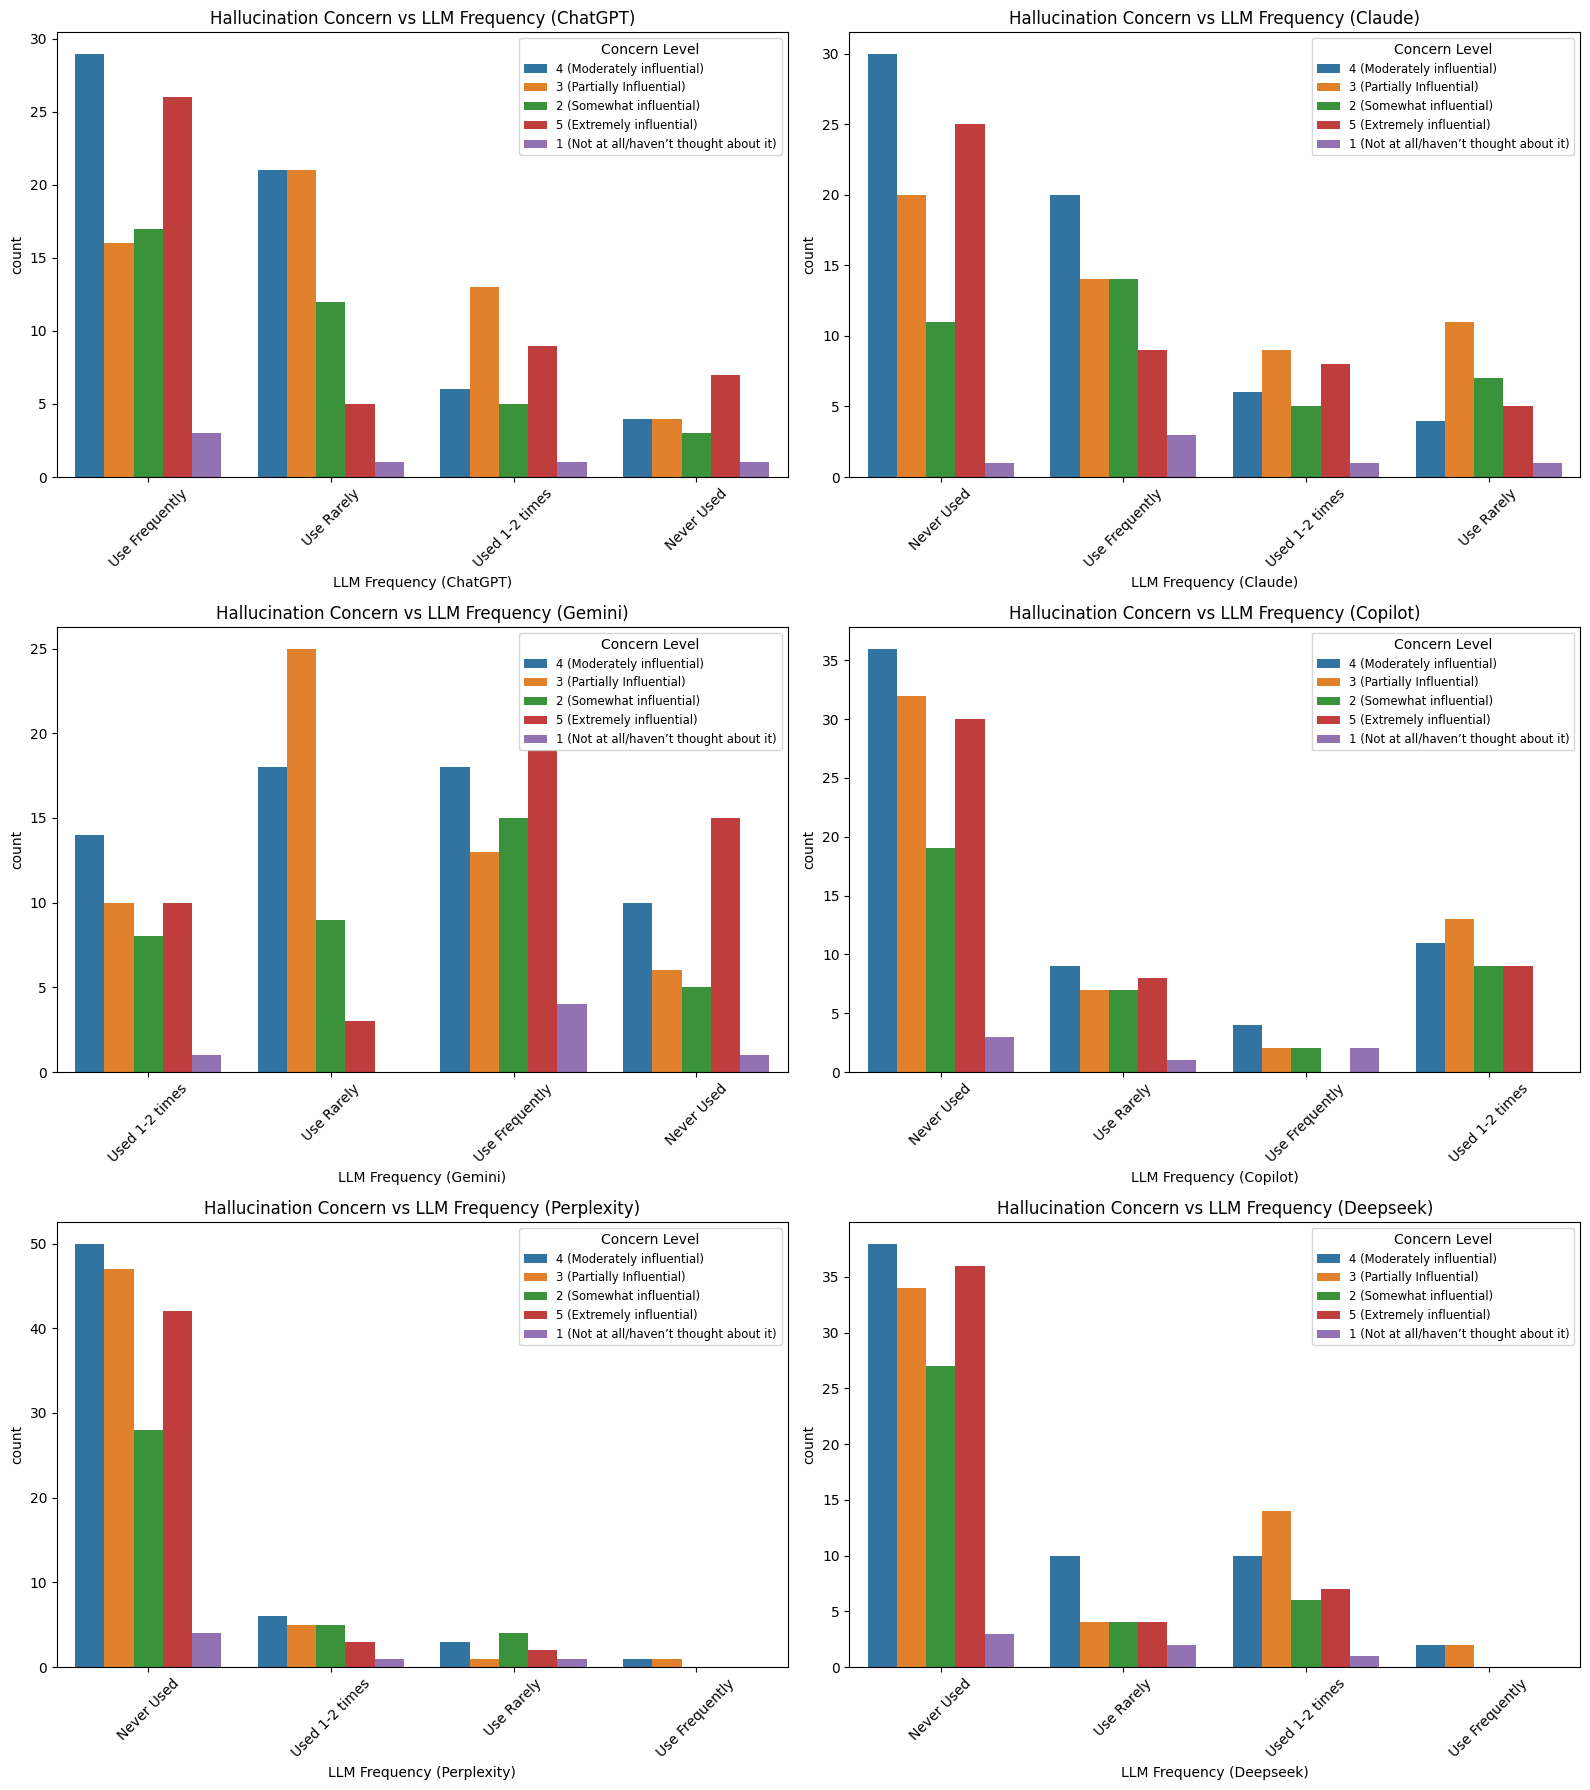

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# List of LLM frequency columns
llms = [
    "LLM Frequency (ChatGPT)",
    "LLM Frequency (Claude)",
    "LLM Frequency (Gemini)",
    "LLM Frequency (Copilot)",
    "LLM Frequency (Perplexity)",
    "LLM Frequency (Deepseek)"
]

# Set up the figure for subplots
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 18))
axes = axes.flatten()

for i, llm in enumerate(llms):
    # Using a countplot to show the distribution of concerns grouped by usage frequency
    sns.countplot(
        data=df_clean,
        x=llm,
        hue="Hallucinations/Wrong Answers",
        ax=axes[i]
    )
    axes[i].set_title(f"Hallucination Concern vs {llm}")
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Concern Level', loc='upper right', fontsize='small')

plt.tight_layout()
plt.show()

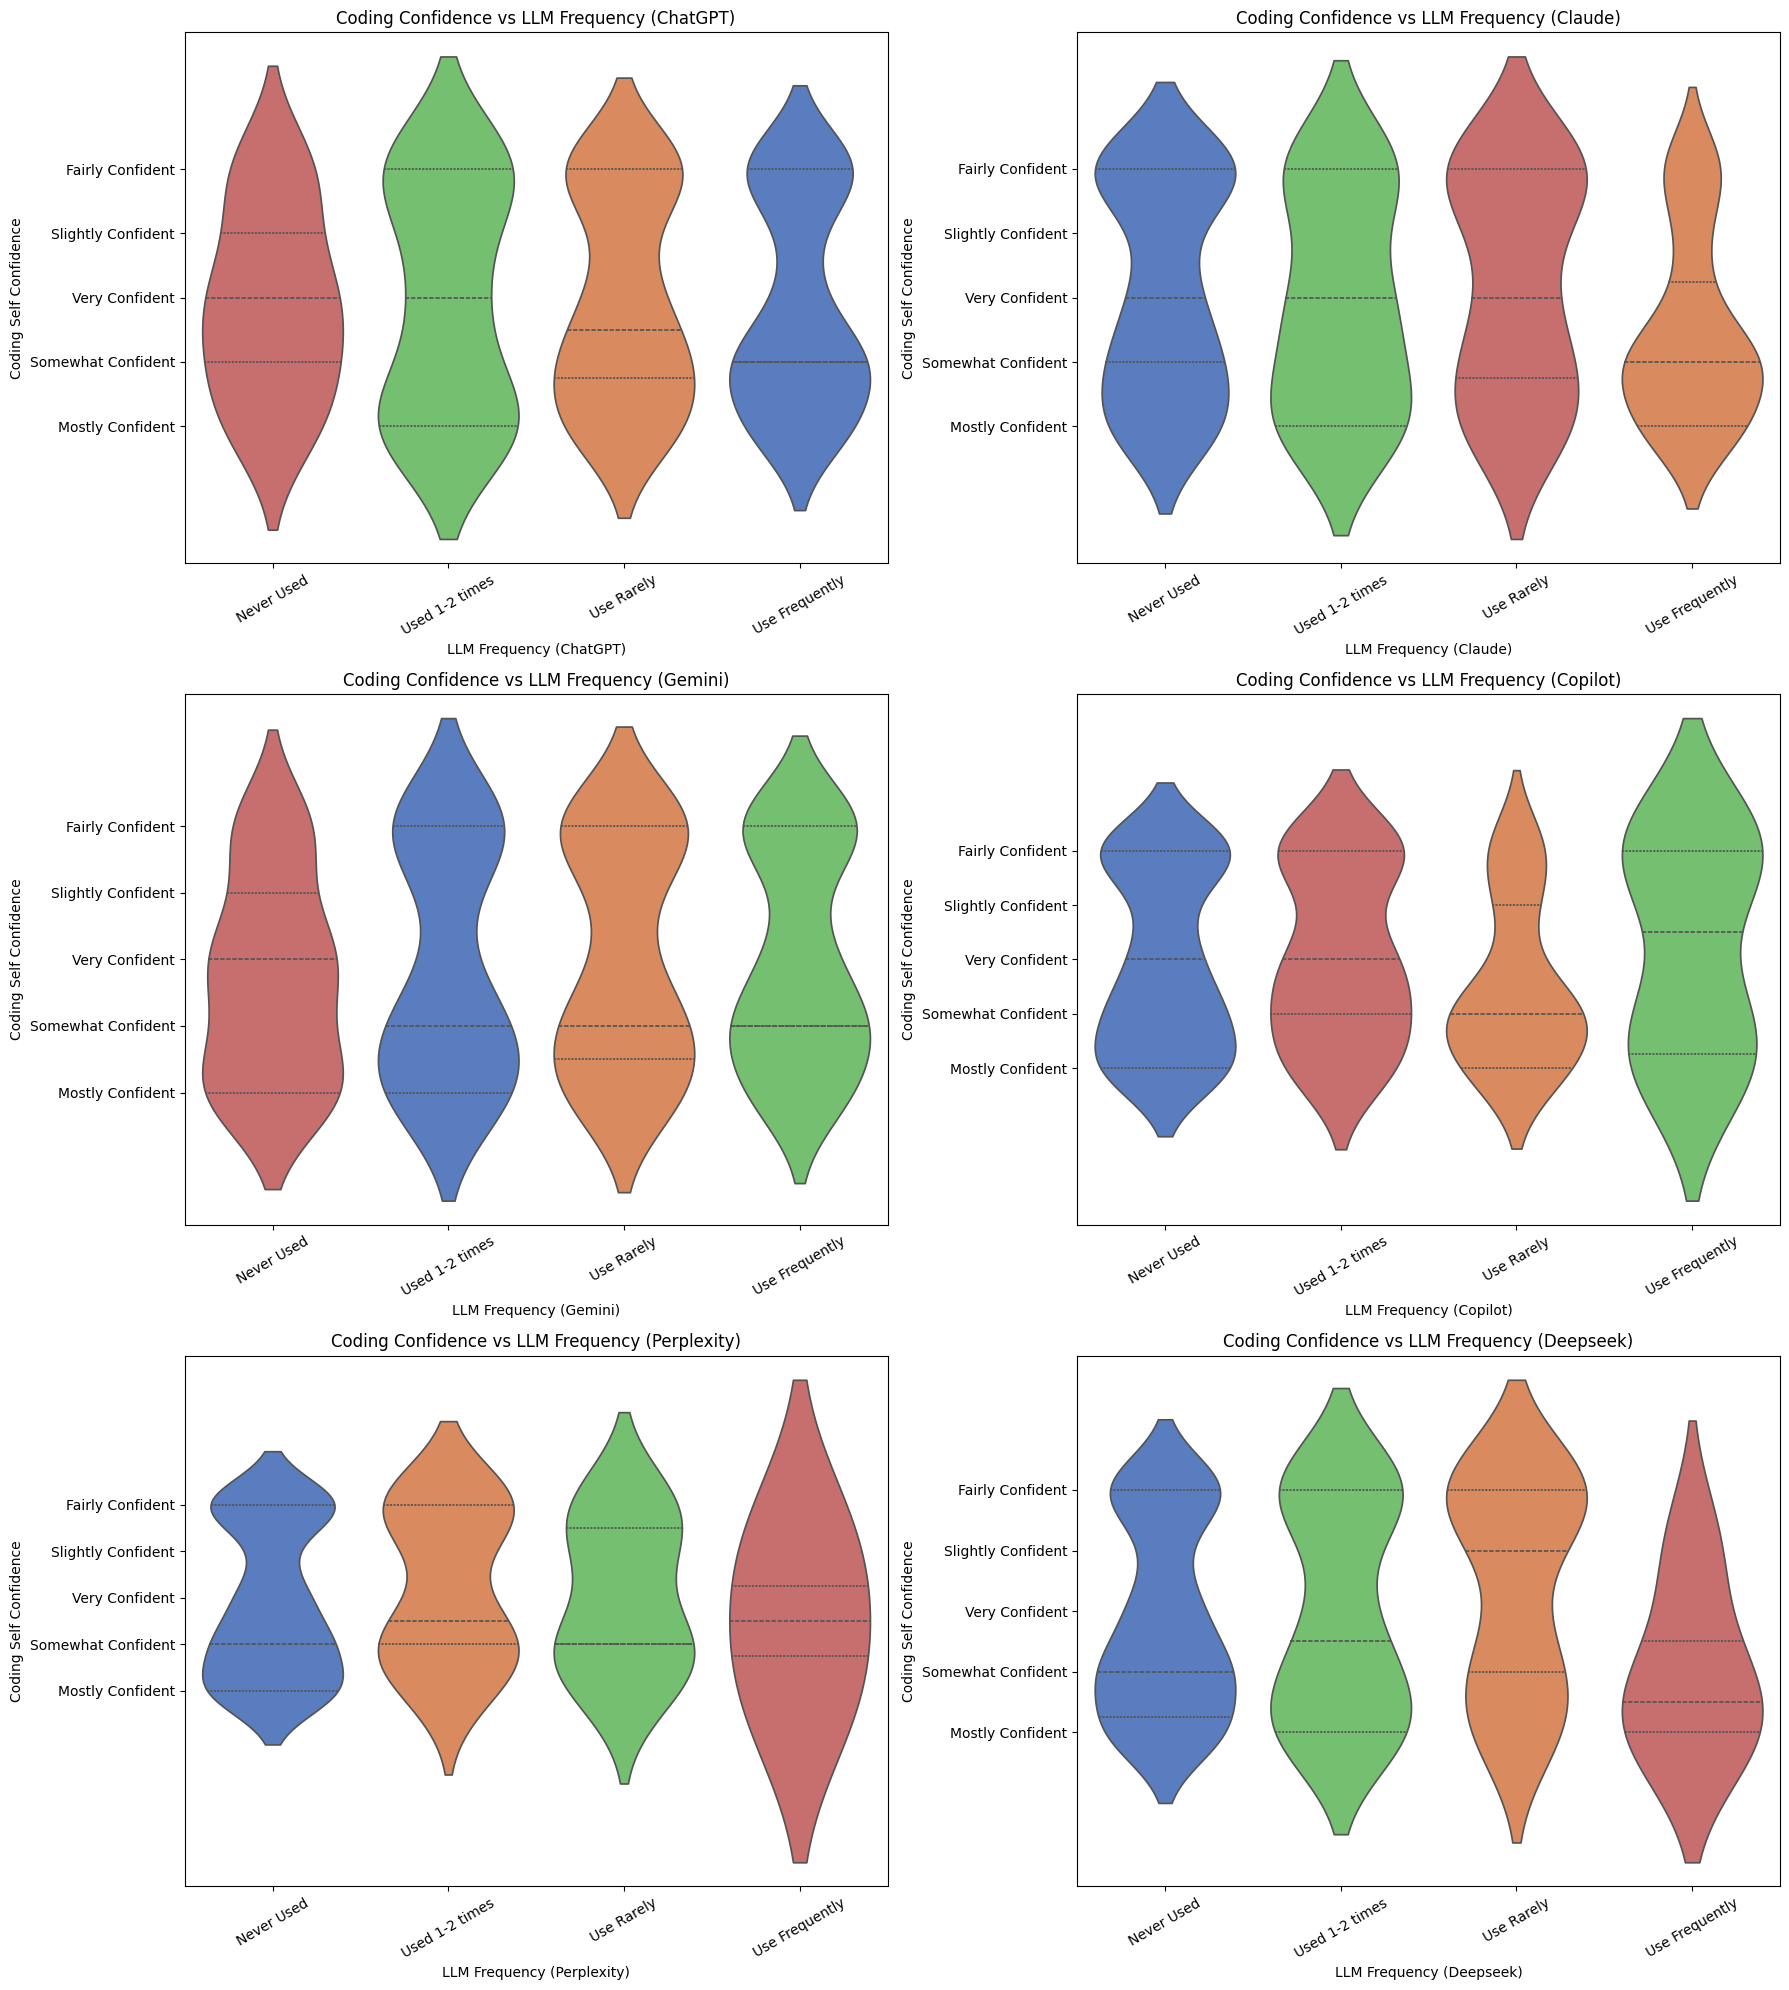

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define logical order for categorical axes
usage_order = ['Never Used', 'Used 1-2 times', 'Use Rarely', 'Use Frequently']

# List of LLM columns
llms = [
    "LLM Frequency (ChatGPT)",
    "LLM Frequency (Claude)",
    "LLM Frequency (Gemini)",
    "LLM Frequency (Copilot)",
    "LLM Frequency (Perplexity)",
    "LLM Frequency (Deepseek)"
]

# Create subplots for each LLM individually
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(18, 20))
axes = axes.flatten()

for i, llm in enumerate(llms):
    # Using violinplot as requested to show distribution density
    sns.violinplot(
        data=df_clean,
        x=llm,
        y='Coding Self Confidence',
        order=[u for u in usage_order if u in df_clean[llm].unique()],
        ax=axes[i],
        palette='muted',
        hue=llm,
        legend=False,
        inner="quartile"
    )
    axes[i].set_title(f'Coding Confidence vs {llm}')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [10]:
from scipy import stats
import pandas as pd

# Map ordinal confidence levels to numeric for testing
confidence_map = {
    'Not Confident at all': 0,
    'Slightly Confident': 1,
    'Somewhat Confident': 2,
    'Fairly Confident': 3,
    'Mostly Confident': 4,
    'Very Confident': 5
}

df_clean['Confidence_Numeric'] = df_clean['Coding Self Confidence'].map(confidence_map)

print("--- Normality Test (Shapiro-Wilk) ---")
# Testing the distribution of confidence across the whole cleaned dataset
shapiro_stat, shapiro_p = stats.shapiro(df_clean['Confidence_Numeric'].dropna())
print(f"Shapiro-Wilk P-value: {shapiro_p:.4f}")
if shapiro_p < 0.05:
    print("Result: Data is likely NOT normally distributed (Reject H0)")
else:
    print("Result: Data appears normally distributed (Fail to reject H0)")

print("\n--- Homogeneity of Variances (Levene's Test) ---")
# We check if variances are equal across different user groups for a primary LLM (e.g., ChatGPT)
groups = [group['Confidence_Numeric'].values for name, group in df_clean.groupby('LLM Frequency (ChatGPT)')]
levene_stat, levene_p = stats.levene(*groups)
print(f"Levene's P-value: {levene_p:.4f}")
if levene_p < 0.05:
    print("Result: Variances are NOT equal (Reject H0)")
else:
    print("Result: Variances are equal (Fail to reject H0)")

print("\n--- Recommendation ---")
if shapiro_p < 0.05 or levene_p < 0.05:
    print("Recommendation: Use Non-Parametric tests (e.g., Kruskal-Wallis H-test) due to violation of assumptions.")
else:
    print("Recommendation: Use Parametric tests (e.g., One-Way ANOVA).")

--- Normality Test (Shapiro-Wilk) ---
Shapiro-Wilk P-value: 0.0000
Result: Data is likely NOT normally distributed (Reject H0)

--- Homogeneity of Variances (Levene's Test) ---
Levene's P-value: 0.2674
Result: Variances are equal (Fail to reject H0)

--- Recommendation ---
Recommendation: Use Non-Parametric tests (e.g., Kruskal-Wallis H-test) due to violation of assumptions.


In [11]:
from scipy.stats import kruskal

results = []

for llm in llms:
    # Prepare groups for Kruskal-Wallis based on usage frequency
    groups = [group['Confidence_Numeric'].dropna().values for name, group in df_clean.groupby(llm)]

    # Only run test if we have at least 2 groups to compare
    if len(groups) > 1:
        h_stat, p_val = kruskal(*groups)
        results.append({
            'LLM': llm,
            'H-statistic': round(h_stat, 4),
            'p-value': round(p_val, 4),
            'Significant (alpha=0.05)': p_val < 0.05
        })

# Display the results in a readable format
results_df = pd.DataFrame(results)
print("--- Kruskal-Wallis H-test Results (Coding Confidence vs Usage Frequency) ---")
print(results_df.to_string(index=False))

--- Kruskal-Wallis H-test Results (Coding Confidence vs Usage Frequency) ---
                       LLM  H-statistic  p-value  Significant (alpha=0.05)
   LLM Frequency (ChatGPT)       7.1134   0.0684                     False
    LLM Frequency (Claude)       5.6281   0.1312                     False
    LLM Frequency (Gemini)       7.0066   0.0717                     False
   LLM Frequency (Copilot)       5.6281   0.1312                     False
LLM Frequency (Perplexity)       7.6656   0.0535                     False
  LLM Frequency (Deepseek)       1.8982   0.5938                     False


In [12]:
try:
    import scikit_posthocs as sp
except ImportError:
    !pip install scikit-posthocs
    import scikit_posthocs as sp

# Filter for Perplexity and perform Dunn's post-hoc test
# We remove NaNs and prepare the data for the post-hoc test
data_perplexity = df_clean[['Confidence_Numeric', 'LLM Frequency (Perplexity)']].dropna()

p_values = sp.posthoc_dunn(
    data_perplexity,
    val_col='Confidence_Numeric',
    group_col='LLM Frequency (Perplexity)',
    p_adjust='holm'
)

print("--- Dunn's Post-hoc Test Results (Perplexity) ---")
display(p_values)

--- Dunn's Post-hoc Test Results (Perplexity) ---


,Never Used,Use Frequently,Use Rarely,Used 1-2 times
Never Used,1.000000,1.0,0.168157,0.396753
Use Frequently,1.000000,1.0,1.000000,1.000000
Use Rarely,0.168157,1.0,1.000000,1.000000
Used 1-2 times,0.396753,1.0,1.000000,1.000000
